# Medical Image Analysis for Skin Lesion Triage

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **Medical Image Analysis for Skin Lesion Triage** and provides the computational implementation for a seven-class dermoscopic image-classification study using the HAM10000 / ISIC 2018 Task 3 training data.

The work is framed as experimental decision support for prioritising lesions for further clinical review. It does not represent autonomous diagnosis, a clinically validated system, or a replacement for specialist assessment. The notebook will develop the analysis in stages, beginning with reproducible project configuration and later covering data integrity, leakage-aware splitting, PyTorch modelling, evaluation, and error analysis.

## Imports and Configuration

This section defines the minimal libraries, central configuration, relative paths, output folders, reproducibility controls, device selection, and lightweight validation helpers required at the start of the workflow.

The notebook is expected to run from the local `python/` directory. Source files are referenced through the sibling `../data/` directory, while generated artefacts are stored under `output/`. Deterministic PyTorch settings are enabled where practical, although exact bitwise reproducibility can still vary across hardware, drivers, and library versions.

In [1]:
# Standard-library imports
import os
import platform
import random
from pathlib import Path

# Configure the CUDA workspace before importing PyTorch.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

# Third-party imports required for initial configuration
import numpy as np
import torch
import torchvision


# Central configuration
random_seed = 42
project_dir = Path.cwd()

data_dir = Path("../data")
image_archive_path = Path("../data/ISIC-images.zip")
metadata_path = Path(
    "../data/challenge-2018-task-3-training_metadata_2026-06-20.csv"
)

output_dir = Path("output")
figures_dir = output_dir / "figures"
tables_dir = output_dir / "tables"
models_dir = output_dir / "models"
metadata_output_dir = output_dir / "metadata"

output_directories = [
    output_dir,
    figures_dir,
    tables_dir,
    models_dir,
    metadata_output_dir,
]

required_source_paths = {
    "image archive": image_archive_path,
    "training metadata": metadata_path,
}


def create_directories(directories: list[Path]) -> None:
    """
    Create the required local directories when they do not already exist.

    Input:
    ------
    directories : list[Path]
        Directory paths to create.

    Outputs:
    --------
    None
        The function creates directories on the local file system.

    Author:
    -------
    Rodrigo Kang
    """
    for directory in directories:
        directory.mkdir(parents=True, exist_ok=True)


def set_reproducibility(seed: int) -> None:
    """
    Apply fixed random seeds and practical deterministic PyTorch settings.

    Input:
    ------
    seed : int
        Random seed used by Python, NumPy, and PyTorch.

    Outputs:
    --------
    None
        The function updates random-number and backend settings in place.

    Author:
    -------
    Rodrigo Kang
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def validate_paths(paths: dict[str, Path]) -> None:
    """
    Confirm that required source paths exist without reading their contents.

    Input:
    ------
    paths : dict[str, Path]
        Descriptive names mapped to required file paths.

    Outputs:
    --------
    None
        The function raises FileNotFoundError when a required path is absent.

    Author:
    -------
    Rodrigo Kang
    """
    missing_paths = [
        f"{name}: {path}"
        for name, path in paths.items()
        if not path.is_file()
    ]

    if missing_paths:
        missing_text = "\n".join(f"- {item}" for item in missing_paths)
        raise FileNotFoundError(
            "Required source files were not found. Run the notebook from the "
            f"python/ directory and confirm these paths:\n{missing_text}"
        )


create_directories(output_directories)
set_reproducibility(random_seed)
validate_paths(required_source_paths)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project directory: {project_dir}")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")

if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

print("Required source paths: available")
print("Output directories: ready")

Project directory: C:\Users\Rodrigo\Desktop\profile\portfolio\notebooks-and-scripts\1-applied-data-science\8-skin-lesion-triage\python
Python: 3.12.13
NumPy: 2.5.1
PyTorch: 2.13.0+cpu
torchvision: 0.28.0+cpu
CUDA available: False
Selected device: cpu
Required source paths: available
Output directories: ready


## Data Loading

This section loads the supplied training metadata and inventories the image archive without extracting it. The audit establishes whether the tabular records, image identifiers and lesion identifiers are internally consistent before any modelling decisions are made.

The collection page reports 10,015 training images and 7,470 specified lesions. The HAM10000 paper describes a multi-source dermoscopic collection assembled from routine practice and research archives, with ground truth based on histopathology where available and otherwise on follow-up, expert consensus or confocal microscopy. These confirmation routes are not equivalent, so their distribution is retained as part of the audit rather than treated as incidental metadata.

The seven target categories follow the ISIC 2018 Task 3 formulation: `akiec`, `bcc`, `bkl`, `df`, `mel`, `nv` and `vasc`. The challenge paper used balanced accuracy because ordinary accuracy is strongly influenced by the uneven class prevalence. It also showed that performance on internally sourced images did not necessarily transfer to an external partition, which limits how far results from this notebook can be generalised.

**Primary references**

- Tschandl, Rosendahl and Kittler (2018), *The HAM10000 dataset, a large collection of multi-source dermatoscopic images of common pigmented skin lesions*.
- Codella et al. (2019), *Skin Lesion Analysis Toward Melanoma Detection 2018: A Challenge Hosted by the International Skin Imaging Collaboration*.
- ISIC Archive, *Challenge 2018: Task 3: Training*, collection 66.

In [2]:
# Imports required for data loading and archive inspection
import io
import zipfile

import pandas as pd
from PIL import Image


class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]


def load_training_metadata(file_path: Path) -> pd.DataFrame:
    """
    Load the supplied ISIC training metadata table.

    Input:
    ------
    file_path : Path
        Relative path to the metadata CSV file.

    Outputs:
    --------
    metadata : pd.DataFrame
        Metadata table with one row per image record.

    Author:
    -------
    Rodrigo Kang
    """
    metadata = pd.read_csv(file_path)

    if metadata.empty:
        raise ValueError("The metadata file contains no records.")

    return metadata


def list_archive_images(archive_path: Path) -> pd.DataFrame:
    """
    Inventory JPEG images stored in the supplied ZIP archive.

    Input:
    ------
    archive_path : Path
        Relative path to the image archive.

    Outputs:
    --------
    archive_inventory : pd.DataFrame
        Image member names, identifiers and compressed file sizes.

    Author:
    -------
    Rodrigo Kang
    """
    with zipfile.ZipFile(archive_path) as archive:
        image_records = [
            {
                "archive_member": member.filename,
                "isic_id": Path(member.filename).stem,
                "compressed_bytes": member.compress_size,
                "uncompressed_bytes": member.file_size,
            }
            for member in archive.infolist()
            if not member.is_dir()
            and Path(member.filename).suffix.lower() in {".jpg", ".jpeg"}
        ]

    archive_inventory = pd.DataFrame(image_records)

    if archive_inventory.empty:
        raise ValueError("No JPEG images were found in the image archive.")

    return archive_inventory


def assign_target_class(metadata: pd.DataFrame) -> pd.Series:
    """
    Map archive diagnosis fields to the seven ISIC 2018 target classes.

    Input:
    ------
    metadata : pd.DataFrame
        Training metadata containing diagnosis fields.

    Outputs:
    --------
    target : pd.Series
        Seven-class target label aligned to the metadata index.

    Author:
    -------
    Rodrigo Kang
    """
    diagnosis_3_mapping = {
        "Nevus": "nv",
        "Melanoma, NOS": "mel",
        "Pigmented benign keratosis": "bkl",
        "Basal cell carcinoma": "bcc",
        "Dermatofibroma": "df",
        "Solar or actinic keratosis": "akiec",
        "Squamous cell carcinoma, NOS": "akiec",
    }

    target = metadata["diagnosis_3"].map(diagnosis_3_mapping)
    vascular_mask = metadata["diagnosis_2"].eq(
        "Benign soft tissue proliferations - Vascular"
    )
    target = target.mask(vascular_mask, "vasc")

    unresolved_rows = metadata.loc[target.isna(), ["diagnosis_2", "diagnosis_3"]]
    if not unresolved_rows.empty:
        unresolved_values = unresolved_rows.drop_duplicates().to_dict("records")
        raise ValueError(
            "Some diagnosis combinations could not be mapped to the seven "
            f"target classes: {unresolved_values}"
        )

    return target


metadata = load_training_metadata(metadata_path)
archive_inventory = list_archive_images(image_archive_path)
metadata = metadata.copy()
metadata["target"] = assign_target_class(metadata)

print(f"Metadata shape: {metadata.shape[0]:,} rows x {metadata.shape[1]:,} columns")
print(f"JPEG images in archive: {len(archive_inventory):,}")
print(f"Unique image identifiers: {metadata['isic_id'].nunique():,}")
print(f"Unique lesion identifiers: {metadata['lesion_id'].nunique():,}")
print(f"Target classes: {sorted(metadata['target'].unique())}")

display(metadata.head())

Metadata shape: 10,015 rows x 18 columns
JPEG images in archive: 10,015
Unique image identifiers: 10,015
Unique lesion identifiers: 7,470
Target classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,isic_id,attribution,copyright_license,age_approx,anatom_site_1,anatom_site_2,anatom_site_3,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_confirm_type,image_type,lesion_id,melanocytic,sex,target
0,ISIC_0024306,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,45.0,Trunk,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_7252831,True,male,nv
1,ISIC_0024307,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,50.0,Lower extremity,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_6125741,True,male,nv
2,ISIC_0024308,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,55.0,Trunk,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_3692653,True,female,nv
3,ISIC_0024309,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,40.0,Trunk,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_0959663,True,male,nv
4,ISIC_0024310,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,60.0,Trunk,Anterior trunk,Anterior chest,NaN,True,Malignant,Malignant melanocytic proliferations (Melanoma),"Melanoma, NOS",histopathology,dermoscopic,IL_8194852,True,male,mel


## Data Preparation

This section reconciles the metadata with the image archive and checks the identifiers that will later govern leakage-aware splitting. It does not create train, validation or test assignments.

An image identifier should occur once in the metadata and once in the archive. A lesion identifier may occur more than once because HAM10000 includes multiple views or acquisitions of some lesions. Those repeated records are legitimate, but every image belonging to the same lesion must remain together when the fixed experimental split is created in a later part.

The audit also records missingness and the distribution of confirmation methods. Histopathology is the strongest available reference standard in this collection, while stable serial imaging, expert consensus and confocal microscopy were used for selected cases described by the dataset authors. These labels remain suitable for the benchmark task, but the mixture should be acknowledged when interpreting model errors.

In [3]:
required_metadata_columns = {
    "isic_id",
    "lesion_id",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
    "diagnosis_confirm_type",
    "age_approx",
    "sex",
    "anatom_site_1",
    "image_type",
    "target",
}
missing_columns = required_metadata_columns.difference(metadata.columns)

if missing_columns:
    raise ValueError(
        "Required metadata columns are missing: "
        f"{sorted(missing_columns)}"
    )

metadata_image_ids = set(metadata["isic_id"])
archive_image_ids = set(archive_inventory["isic_id"])

metadata_without_image = sorted(metadata_image_ids - archive_image_ids)
images_without_metadata = sorted(archive_image_ids - metadata_image_ids)

images_per_lesion = metadata.groupby("lesion_id").size().rename("image_count")
lesion_count_distribution = (
    images_per_lesion.value_counts()
    .sort_index()
    .rename_axis("images_per_lesion")
    .reset_index(name="lesion_count")
)

missingness_summary = (
    metadata.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda table: 100 * table["missing_count"] / len(metadata))
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
    .reset_index(names="column")
)

class_distribution = (
    metadata["target"]
    .value_counts()
    .reindex(class_names)
    .rename("image_count")
    .to_frame()
    .assign(image_percent=lambda table: 100 * table["image_count"] / len(metadata))
    .reset_index(names="target")
)

confirmation_distribution = (
    metadata["diagnosis_confirm_type"]
    .value_counts(dropna=False)
    .rename("image_count")
    .to_frame()
    .assign(image_percent=lambda table: 100 * table["image_count"] / len(metadata))
    .reset_index(names="diagnosis_confirm_type")
)

integrity_summary = pd.DataFrame(
    {
        "check": [
            "metadata rows",
            "archive JPEG images",
            "duplicate metadata rows",
            "duplicate metadata image identifiers",
            "duplicate archive image identifiers",
            "metadata records without image",
            "archive images without metadata",
            "unique lesions",
            "lesions with multiple images",
        ],
        "value": [
            len(metadata),
            len(archive_inventory),
            int(metadata.duplicated().sum()),
            int(metadata["isic_id"].duplicated().sum()),
            int(archive_inventory["isic_id"].duplicated().sum()),
            len(metadata_without_image),
            len(images_without_metadata),
            metadata["lesion_id"].nunique(),
            int((images_per_lesion > 1).sum()),
        ],
    }
)

if set(metadata["target"].unique()) != set(class_names):
    raise ValueError("The derived target does not contain the expected seven classes.")

if metadata_without_image or images_without_metadata:
    raise ValueError(
        "Metadata and archive identifiers do not reconcile. "
        f"Metadata without image: {len(metadata_without_image)}; "
        f"images without metadata: {len(images_without_metadata)}."
    )

integrity_summary.to_csv(
    tables_dir / "data-integrity-summary.csv", index=False
)
missingness_summary.to_csv(
    tables_dir / "metadata-missingness.csv", index=False
)
class_distribution.to_csv(
    tables_dir / "class-distribution.csv", index=False
)
confirmation_distribution.to_csv(
    tables_dir / "confirmation-methods.csv", index=False
)
lesion_count_distribution.to_csv(
    tables_dir / "images-per-lesion.csv", index=False
)

print("Identifier reconciliation: passed")
print(f"Lesions with multiple images: {(images_per_lesion > 1).sum():,}")
print(f"Maximum images for one lesion: {images_per_lesion.max():,}")

display(integrity_summary)
display(class_distribution)
display(confirmation_distribution)
display(missingness_summary)

Identifier reconciliation: passed
Lesions with multiple images: 1,956
Maximum images for one lesion: 6


,check,value
0,metadata rows,10015
1,archive JPEG images,10015
2,duplicate metadata rows,0
3,duplicate metadata image identifiers,0
4,duplicate archive image identifiers,0
5,metadata records without image,0
6,archive images without metadata,0
7,unique lesions,7470
8,lesions with multiple images,1956


,target,image_count,image_percent
0,akiec,327,3.265102
1,bcc,514,5.132302
2,bkl,1099,10.973540
3,df,115,1.148278
4,mel,1113,11.113330
5,nv,6705,66.949576
6,vasc,142,1.417873


,diagnosis_confirm_type,image_count,image_percent
0,histopathology,5340,53.320020
1,serial imaging showing no change,3704,36.984523
2,single image expert consensus,902,9.006490
3,confocal microscopy with consensus dermoscopy,69,0.688967


,column,missing_count,missing_percent
0,anatom_site_special,9551,95.366950
1,anatom_site_3,7657,76.455317
2,anatom_site_2,4840,48.327509
3,anatom_site_1,241,2.406390
4,diagnosis_3,142,1.417873
5,age_approx,94,0.938592
6,sex,47,0.469296


## Exploratory Analysis (Optional)

This section completes a bounded image-level audit directly inside the ZIP archive. Every JPEG is opened and verified without extracting the collection. The check records image dimensions, colour mode and format, and reports unreadable files.

The resulting summaries establish whether a single loading strategy is appropriate. They are not an analysis of lesion appearance, demographics or model inputs; those exploratory questions remain for the next part. Only a compact class-distribution plot is included here to make the imbalance visible before the evaluation protocol is defined.

Images verified: 10,015
Unreadable images: 0


,width,height,mode,format,image_count
0,600,450,RGB,JPEG,10015


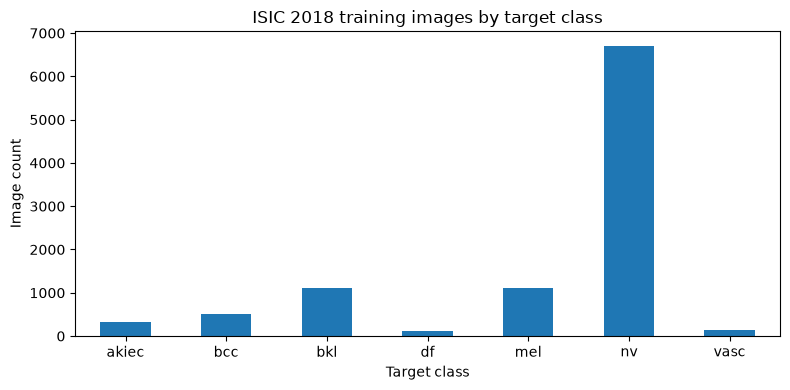

In [4]:
import matplotlib.pyplot as plt


def audit_archive_images(
    archive_path: Path,
    image_members: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Verify archived images and summarise their technical properties.

    Input:
    ------
    archive_path : Path
        Relative path to the ZIP archive containing the images.
    image_members : pd.Series
        Archive member names for the JPEG images to inspect.

    Outputs:
    --------
    image_properties : pd.DataFrame
        Technical properties recorded for readable images.
    image_errors : pd.DataFrame
        Member names and error messages for unreadable images.

    Author:
    -------
    Rodrigo Kang
    """
    property_records = []
    error_records = []

    with zipfile.ZipFile(archive_path) as archive:
        for member_name in image_members:
            try:
                image_bytes = archive.read(member_name)

                with Image.open(io.BytesIO(image_bytes)) as image:
                    image.verify()

                with Image.open(io.BytesIO(image_bytes)) as image:
                    property_records.append(
                        {
                            "archive_member": member_name,
                            "width": image.width,
                            "height": image.height,
                            "mode": image.mode,
                            "format": image.format,
                        }
                    )
            except (OSError, ValueError, zipfile.BadZipFile) as error:
                error_records.append(
                    {
                        "archive_member": member_name,
                        "error": str(error),
                    }
                )

    image_properties = pd.DataFrame(property_records)
    image_errors = pd.DataFrame(
        error_records,
        columns=["archive_member", "error"],
    )

    return image_properties, image_errors


image_properties, image_errors = audit_archive_images(
    image_archive_path,
    archive_inventory["archive_member"],
)

image_property_summary = (
    image_properties.groupby(["width", "height", "mode", "format"])
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values("image_count", ascending=False)
)

image_property_summary.to_csv(
    tables_dir / "image-property-summary.csv", index=False
)
image_errors.to_csv(
    tables_dir / "unreadable-images.csv", index=False
)

print(f"Images verified: {len(image_properties):,}")
print(f"Unreadable images: {len(image_errors):,}")
display(image_property_summary)

class_plot = class_distribution.set_index("target")["image_count"]
axis = class_plot.plot(kind="bar", figsize=(8, 4))
axis.set_title("ISIC 2018 training images by target class")
axis.set_xlabel("Target class")
axis.set_ylabel("Image count")
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(
    figures_dir / "class-distribution.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## Methodology

This section defines a leakage-aware experimental protocol for the seven-class classification task. Images are split by `lesion_id`, rather than by image identifier, so that multiple photographs of the same lesion cannot appear in different subsets. The resulting train, validation and test partitions are approximately 71%, 14% and 14% of the available images.

The training pipeline uses moderate geometric and colour augmentation, while validation and test images receive deterministic resizing and normalisation. ImageNet statistics are used because the transfer-learning model introduced in the next section will begin from ImageNet-pretrained weights.

Class imbalance is handled through inverse-square-root class weights in the loss function. This is less aggressive than direct inverse-frequency weighting and reduces the risk that a small class dominates gradient updates. The split itself remains stratified at lesion level, and all partitions are audited before model development begins.


In [ ]:
# Imports required for splitting, transformations and data loading
from collections.abc import Callable
from typing import Optional

from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms


# Experimental configuration
image_size = 224
batch_size = 32
number_of_workers = 0  # Reliable default for Windows and ZIP-backed loading.
pin_memory = torch.cuda.is_available()

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

class_to_index = {
    class_name: class_index
    for class_index, class_name in enumerate(class_names)
}
index_to_class = {
    class_index: class_name
    for class_name, class_index in class_to_index.items()
}


def validate_lesion_targets(metadata_table: pd.DataFrame) -> None:
    """
    Confirm that each lesion identifier maps to a single target class.

    Input:
    ------
    metadata_table : pd.DataFrame
        Image-level metadata containing lesion and target identifiers.

    Outputs:
    --------
    None
        The function raises ValueError when a lesion has conflicting labels.

    Author:
    -------
    Rodrigo Kang
    """
    targets_per_lesion = metadata_table.groupby("lesion_id")["target"].nunique()
    conflicting_lesions = targets_per_lesion[targets_per_lesion > 1]

    if not conflicting_lesions.empty:
        raise ValueError(
            "Some lesion identifiers map to more than one target class: "
            f"{conflicting_lesions.index.tolist()[:10]}"
        )


def create_group_stratified_splits(
    metadata_table: pd.DataFrame,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Create lesion-disjoint train, validation and test partitions.

    Input:
    ------
    metadata_table : pd.DataFrame
        Image-level metadata with target labels and lesion identifiers.
    seed : int
        Random seed used by the stratified group splitters.

    Outputs:
    --------
    train_metadata : pd.DataFrame
        Training records.
    validation_metadata : pd.DataFrame
        Validation records.
    test_metadata : pd.DataFrame
        Held-out test records.

    Author:
    -------
    Rodrigo Kang
    """
    validate_lesion_targets(metadata_table)

    outer_splitter = StratifiedGroupKFold(
        n_splits=7,
        shuffle=True,
        random_state=seed,
    )
    development_indices, test_indices = next(
        outer_splitter.split(
            metadata_table,
            y=metadata_table["target"],
            groups=metadata_table["lesion_id"],
        )
    )

    development_metadata = metadata_table.iloc[development_indices].copy()
    test_metadata = metadata_table.iloc[test_indices].copy()

    inner_splitter = StratifiedGroupKFold(
        n_splits=6,
        shuffle=True,
        random_state=seed + 1,
    )
    train_indices, validation_indices = next(
        inner_splitter.split(
            development_metadata,
            y=development_metadata["target"],
            groups=development_metadata["lesion_id"],
        )
    )

    train_metadata = development_metadata.iloc[train_indices].copy()
    validation_metadata = development_metadata.iloc[validation_indices].copy()

    for split_table in (train_metadata, validation_metadata, test_metadata):
        split_table["target_index"] = (
            split_table["target"].map(class_to_index).astype("int64")
        )
        split_table.reset_index(drop=True, inplace=True)

    return train_metadata, validation_metadata, test_metadata


def audit_split_integrity(
    train_metadata: pd.DataFrame,
    validation_metadata: pd.DataFrame,
    test_metadata: pd.DataFrame,
) -> pd.DataFrame:
    """
    Verify lesion separation and summarise split composition.

    Input:
    ------
    train_metadata : pd.DataFrame
        Training records.
    validation_metadata : pd.DataFrame
        Validation records.
    test_metadata : pd.DataFrame
        Test records.

    Outputs:
    --------
    split_summary : pd.DataFrame
        Image, lesion and class counts for each split.

    Author:
    -------
    Rodrigo Kang
    """
    train_lesions = set(train_metadata["lesion_id"])
    validation_lesions = set(validation_metadata["lesion_id"])
    test_lesions = set(test_metadata["lesion_id"])

    overlap_counts = {
        "train_validation": len(train_lesions & validation_lesions),
        "train_test": len(train_lesions & test_lesions),
        "validation_test": len(validation_lesions & test_lesions),
    }

    if any(overlap_counts.values()):
        raise ValueError(
            "Lesion leakage was detected between data partitions: "
            f"{overlap_counts}"
        )

    split_tables = {
        "train": train_metadata,
        "validation": validation_metadata,
        "test": test_metadata,
    }
    summary_records = []

    for split_name, split_table in split_tables.items():
        class_counts = split_table["target"].value_counts()

        summary_record = {
            "split": split_name,
            "image_count": len(split_table),
            "image_percent": 100 * len(split_table) / len(metadata),
            "lesion_count": split_table["lesion_id"].nunique(),
        }
        summary_record.update(
            {
                f"{class_name}_count": int(class_counts.get(class_name, 0))
                for class_name in class_names
            }
        )
        summary_records.append(summary_record)

    return pd.DataFrame(summary_records)


class ZipImageDataset(Dataset):
    """
    Load dermoscopic images lazily from a ZIP archive.

    The dataset keeps one archive handle per process. The notebook uses
    ``num_workers=0`` by default, which is the most reliable Windows setting
    for a ZIP-backed dataset.
    """

    def __init__(
        self,
        metadata_table: pd.DataFrame,
        archive_path: Path,
        archive_lookup: dict[str, str],
        transform: Optional[Callable] = None,
    ) -> None:
        """
        Initialise the ZIP-backed image dataset.

        Input:
        ------
        metadata_table : pd.DataFrame
            Records containing image identifiers and integer targets.
        archive_path : Path
            Path to the ZIP archive.
        archive_lookup : dict[str, str]
            Mapping from image identifier to archive member name.
        transform : Optional[Callable]
            Image transformation pipeline.

        Outputs:
        --------
        None
            The dataset stores the supplied configuration.

        Author:
        -------
        Rodrigo Kang
        """
        self.metadata_table = metadata_table.reset_index(drop=True).copy()
        self.archive_path = Path(archive_path)
        self.archive_lookup = archive_lookup
        self.transform = transform
        self._archive = None

    def __len__(self) -> int:
        """Return the number of image records in the dataset."""
        return len(self.metadata_table)

    def _get_archive(self) -> zipfile.ZipFile:
        """Open the ZIP archive lazily and reuse the process-local handle."""
        if self._archive is None:
            self._archive = zipfile.ZipFile(self.archive_path)
        return self._archive

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int, str]:
        """
        Read and transform one image.

        Input:
        ------
        index : int
            Positional dataset index.

        Outputs:
        --------
        image_tensor : torch.Tensor
            Transformed RGB image tensor.
        target_index : int
            Integer target label.
        image_identifier : str
            ISIC image identifier.

        Author:
        -------
        Rodrigo Kang
        """
        record = self.metadata_table.iloc[index]
        image_identifier = record["isic_id"]
        member_name = self.archive_lookup[image_identifier]

        archive = self._get_archive()
        image_bytes = archive.read(member_name)

        with Image.open(io.BytesIO(image_bytes)) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)

        return image, int(record["target_index"]), image_identifier

    def close(self) -> None:
        """Close the archive handle when it is no longer needed."""
        if self._archive is not None:
            self._archive.close()
            self._archive = None

    def __del__(self) -> None:
        """Release the archive handle during object cleanup."""
        self.close()


train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            image_size,
            scale=(0.80, 1.00),
            ratio=(0.90, 1.10),
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

train_metadata, validation_metadata, test_metadata = (
    create_group_stratified_splits(metadata, random_seed)
)

split_summary = audit_split_integrity(
    train_metadata,
    validation_metadata,
    test_metadata,
)

archive_lookup = dict(
    zip(
        archive_inventory["isic_id"],
        archive_inventory["archive_member"],
    )
)

train_dataset = ZipImageDataset(
    train_metadata,
    image_archive_path,
    archive_lookup,
    transform=train_transform,
)
validation_dataset = ZipImageDataset(
    validation_metadata,
    image_archive_path,
    archive_lookup,
    transform=evaluation_transform,
)
test_dataset = ZipImageDataset(
    test_metadata,
    image_archive_path,
    archive_lookup,
    transform=evaluation_transform,
)

data_loader_generator = torch.Generator()
data_loader_generator.manual_seed(random_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=number_of_workers,
    pin_memory=pin_memory,
    generator=data_loader_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=number_of_workers,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=number_of_workers,
    pin_memory=pin_memory,
)

train_class_counts = (
    train_metadata["target"]
    .value_counts()
    .reindex(class_names)
    .astype("float32")
)

class_weights = np.sqrt(
    train_class_counts.sum() / train_class_counts.to_numpy()
)
class_weights = class_weights / class_weights.mean()
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

split_summary.to_csv(
    tables_dir / "data-split-summary.csv",
    index=False,
)
train_metadata.to_csv(
    metadata_output_dir / "train-metadata.csv",
    index=False,
)
validation_metadata.to_csv(
    metadata_output_dir / "validation-metadata.csv",
    index=False,
)
test_metadata.to_csv(
    metadata_output_dir / "test-metadata.csv",
    index=False,
)

class_weight_summary = pd.DataFrame(
    {
        "target": class_names,
        "train_image_count": train_class_counts.to_numpy(dtype="int64"),
        "loss_weight": class_weights,
    }
)
class_weight_summary.to_csv(
    tables_dir / "class-weights.csv",
    index=False,
)

sample_images, sample_targets, sample_identifiers = next(iter(train_loader))

if sample_images.shape[1:] != (3, image_size, image_size):
    raise ValueError(
        "Unexpected training batch shape: "
        f"{tuple(sample_images.shape)}"
    )

print("Lesion-level split integrity: passed")
print(f"Training batches: {len(train_loader):,}")
print(f"Validation batches: {len(validation_loader):,}")
print(f"Test batches: {len(test_loader):,}")
print(f"Sample batch shape: {tuple(sample_images.shape)}")
print(f"Class order: {class_names}")

display(split_summary)
display(class_weight_summary)


## Model Development

This section defines two complementary image classifiers. The first is a compact convolutional neural network trained from scratch. It provides a transparent baseline and helps distinguish gains from transfer learning from gains produced by the broader experimental pipeline.

The second model is a ResNet-18 initialised from ImageNet weights. Its classification head is replaced for the seven lesion classes, while the convolutional backbone is initially frozen. This staged design keeps the first optimisation phase computationally modest and reduces the risk of unstable updates before the new head has adapted to the task.

The notebook reports total and trainable parameter counts and performs a forward-pass check on a real training batch. These checks ensure that both architectures produce logits with the expected shape before training begins.


In [ ]:
# Imports required for model construction
import warnings

import torch.nn as nn
from torchvision.models import ResNet18_Weights, resnet18


class CompactConvolutionalNetwork(nn.Module):
    """
    Define a compact convolutional baseline for seven-class classification.

    The network uses four convolutional stages with batch normalisation,
    ReLU activations and spatial downsampling. Adaptive pooling removes any
    dependence on the exact input dimensions before the classification head.
    """

    def __init__(
        self,
        number_of_classes: int,
        dropout_probability: float = 0.30,
    ) -> None:
        """
        Initialise the compact convolutional classifier.

        Input:
        ------
        number_of_classes : int
            Number of output classes.
        dropout_probability : float
            Dropout probability used in the classification head.

        Outputs:
        --------
        None
            The model layers are initialised in place.

        Author:
        -------
        Rodrigo Kang
        """
        super().__init__()

        self.feature_extractor = nn.Sequential(
            self._convolutional_block(3, 32),
            self._convolutional_block(32, 64),
            self._convolutional_block(64, 128),
            self._convolutional_block(128, 256),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(256, number_of_classes),
        )

    @staticmethod
    def _convolutional_block(
        input_channels: int,
        output_channels: int,
    ) -> nn.Sequential:
        """
        Create one convolutional feature-extraction block.

        Input:
        ------
        input_channels : int
            Number of channels entering the block.
        output_channels : int
            Number of channels produced by the block.

        Outputs:
        --------
        block : nn.Sequential
            Convolution, normalisation, activation and pooling operations.

        Author:
        -------
        Rodrigo Kang
        """
        return nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

    def forward(self, image_batch: torch.Tensor) -> torch.Tensor:
        """
        Produce class logits for a batch of images.

        Input:
        ------
        image_batch : torch.Tensor
            Tensor with shape ``(batch, 3, height, width)``.

        Outputs:
        --------
        logits : torch.Tensor
            Unnormalised class scores.

        Author:
        -------
        Rodrigo Kang
        """
        features = self.feature_extractor(image_batch)
        return self.classifier(features)


def build_resnet18_classifier(
    number_of_classes: int,
    use_pretrained_weights: bool = True,
    freeze_backbone: bool = True,
    dropout_probability: float = 0.20,
) -> nn.Module:
    """
    Build a ResNet-18 classifier for the lesion classification task.

    Input:
    ------
    number_of_classes : int
        Number of output classes.
    use_pretrained_weights : bool
        Whether to request ImageNet-pretrained weights.
    freeze_backbone : bool
        Whether to freeze convolutional backbone parameters initially.
    dropout_probability : float
        Dropout probability used before the final linear layer.

    Outputs:
    --------
    model : nn.Module
        Configured ResNet-18 classifier.

    Author:
    -------
    Rodrigo Kang
    """
    requested_weights = (
        ResNet18_Weights.DEFAULT if use_pretrained_weights else None
    )

    try:
        model = resnet18(weights=requested_weights)
        pretrained_weights_loaded = requested_weights is not None
    except Exception as error:
        if not use_pretrained_weights:
            raise

        warnings.warn(
            "ImageNet weights could not be loaded. The model will use "
            f"random initialisation instead. Original error: {error}",
            RuntimeWarning,
        )
        model = resnet18(weights=None)
        pretrained_weights_loaded = False

    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False

    input_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_probability),
        nn.Linear(input_features, number_of_classes),
    )

    model.pretrained_weights_loaded = pretrained_weights_loaded
    model.backbone_frozen = freeze_backbone

    return model


def count_model_parameters(model: nn.Module) -> dict[str, int]:
    """
    Count total and trainable parameters in a PyTorch model.

    Input:
    ------
    model : nn.Module
        Model whose parameters will be counted.

    Outputs:
    --------
    parameter_counts : dict[str, int]
        Total, trainable and frozen parameter counts.

    Author:
    -------
    Rodrigo Kang
    """
    total_parameters = sum(
        parameter.numel() for parameter in model.parameters()
    )
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return {
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "frozen_parameters": total_parameters - trainable_parameters,
    }


def check_model_output(
    model: nn.Module,
    image_batch: torch.Tensor,
    expected_number_of_classes: int,
) -> tuple[int, ...]:
    """
    Confirm that a model returns correctly shaped logits.

    Input:
    ------
    model : nn.Module
        Image classifier to validate.
    image_batch : torch.Tensor
        Real batch produced by the training DataLoader.
    expected_number_of_classes : int
        Expected width of the output logits.

    Outputs:
    --------
    output_shape : tuple[int, ...]
        Shape of the model logits.

    Author:
    -------
    Rodrigo Kang
    """
    model = model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(image_batch.to(device))

    expected_shape = (
        image_batch.shape[0],
        expected_number_of_classes,
    )

    if tuple(logits.shape) != expected_shape:
        raise ValueError(
            f"Unexpected model output shape {tuple(logits.shape)}; "
            f"expected {expected_shape}."
        )

    return tuple(logits.shape)


number_of_classes = len(class_names)

compact_cnn = CompactConvolutionalNetwork(
    number_of_classes=number_of_classes,
    dropout_probability=0.30,
)

transfer_model = build_resnet18_classifier(
    number_of_classes=number_of_classes,
    use_pretrained_weights=True,
    freeze_backbone=True,
    dropout_probability=0.20,
)

model_registry = {
    "compact_cnn": compact_cnn,
    "resnet18_transfer": transfer_model,
}

model_summary_records = []

for model_name, model in model_registry.items():
    parameter_counts = count_model_parameters(model)
    output_shape = check_model_output(
        model=model,
        image_batch=sample_images,
        expected_number_of_classes=number_of_classes,
    )

    model_summary_records.append(
        {
            "model": model_name,
            **parameter_counts,
            "output_shape": str(output_shape),
            "pretrained_weights_loaded": getattr(
                model,
                "pretrained_weights_loaded",
                False,
            ),
            "backbone_frozen": getattr(
                model,
                "backbone_frozen",
                False,
            ),
        }
    )

    model.to("cpu")

model_summary = pd.DataFrame(model_summary_records)

model_summary.to_csv(
    tables_dir / "model-architecture-summary.csv",
    index=False,
)

architecture_metadata = {
    "image_size": image_size,
    "number_of_classes": number_of_classes,
    "class_order": class_names,
    "baseline_model": "CompactConvolutionalNetwork",
    "transfer_model": "ResNet-18",
    "transfer_learning_weights": (
        "ImageNet-1K V1"
        if transfer_model.pretrained_weights_loaded
        else "random initialisation"
    ),
    "initial_backbone_state": "frozen",
}

with (metadata_output_dir / "model-architecture.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(architecture_metadata, file, indent=2)

print("Model construction checks: passed")
print(
    "Transfer-learning weights loaded: "
    f"{transfer_model.pretrained_weights_loaded}"
)

display(model_summary)


## Training and Validation

This section trains the compact baseline and the transfer-learning model under the same data partitions and class-weighted objective. Model selection is based on validation macro F1 rather than raw accuracy because the class distribution is strongly imbalanced and performance on minority classes matters for a triage-oriented application.

The compact CNN is trained end to end. The ResNet-18 experiment begins with its convolutional backbone frozen and optimises only the new classification head. Both experiments use AdamW, validation-based learning-rate reduction, gradient clipping and early stopping. The best checkpoint from each run is retained, rather than the weights from the final epoch.

The default epoch counts are deliberately modest so that the notebook remains practical on a CPU-only machine. They provide a defensible first comparison, while the configuration block can be increased later without changing the training logic.


In [ ]:
# Imports required for optimisation and validation
import copy
import time

from sklearn.metrics import balanced_accuracy_score, f1_score


training_configuration = {
    "compact_cnn": {
        "maximum_epochs": 8,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "early_stopping_patience": 3,
    },
    "resnet18_transfer": {
        "maximum_epochs": 6,
        "learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "early_stopping_patience": 3,
    },
}

gradient_clip_norm = 1.0


def calculate_classification_metrics(
    targets: list[int],
    predictions: list[int],
) -> dict[str, float]:
    """
    Calculate imbalance-aware classification metrics.

    Input:
    ------
    targets : list[int]
        Ground-truth class indices.
    predictions : list[int]
        Predicted class indices.

    Outputs:
    --------
    metrics : dict[str, float]
        Balanced accuracy and macro F1.

    Author:
    -------
    Rodrigo Kang
    """
    return {
        "balanced_accuracy": balanced_accuracy_score(
            targets,
            predictions,
        ),
        "macro_f1": f1_score(
            targets,
            predictions,
            average="macro",
            zero_division=0,
        ),
    }


def run_training_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimiser: torch.optim.Optimizer,
) -> dict[str, float]:
    """
    Train a model for one complete epoch.

    Input:
    ------
    model : nn.Module
        Model being optimised.
    data_loader : DataLoader
        Training data loader.
    loss_function : nn.Module
        Classification loss.
    optimiser : torch.optim.Optimizer
        Parameter optimiser.

    Outputs:
    --------
    epoch_metrics : dict[str, float]
        Mean loss, balanced accuracy and macro F1.

    Author:
    -------
    Rodrigo Kang
    """
    model.train()

    accumulated_loss = 0.0
    observed_targets = []
    observed_predictions = []

    for image_batch, target_batch, _ in data_loader:
        image_batch = image_batch.to(device, non_blocking=True)
        target_batch = target_batch.to(device, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)

        logits = model(image_batch)
        loss = loss_function(logits, target_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=gradient_clip_norm,
        )
        optimiser.step()

        batch_size_observed = image_batch.size(0)
        accumulated_loss += loss.item() * batch_size_observed

        predictions = logits.argmax(dim=1)
        observed_targets.extend(target_batch.detach().cpu().tolist())
        observed_predictions.extend(predictions.detach().cpu().tolist())

    classification_metrics = calculate_classification_metrics(
        observed_targets,
        observed_predictions,
    )

    return {
        "loss": accumulated_loss / len(data_loader.dataset),
        **classification_metrics,
    }


def run_validation_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
) -> dict[str, float]:
    """
    Evaluate a model without updating its parameters.

    Input:
    ------
    model : nn.Module
        Model being evaluated.
    data_loader : DataLoader
        Validation data loader.
    loss_function : nn.Module
        Classification loss.

    Outputs:
    --------
    epoch_metrics : dict[str, float]
        Mean loss, balanced accuracy and macro F1.

    Author:
    -------
    Rodrigo Kang
    """
    model.eval()

    accumulated_loss = 0.0
    observed_targets = []
    observed_predictions = []

    with torch.inference_mode():
        for image_batch, target_batch, _ in data_loader:
            image_batch = image_batch.to(device, non_blocking=True)
            target_batch = target_batch.to(device, non_blocking=True)

            logits = model(image_batch)
            loss = loss_function(logits, target_batch)

            batch_size_observed = image_batch.size(0)
            accumulated_loss += loss.item() * batch_size_observed

            predictions = logits.argmax(dim=1)
            observed_targets.extend(target_batch.cpu().tolist())
            observed_predictions.extend(predictions.cpu().tolist())

    classification_metrics = calculate_classification_metrics(
        observed_targets,
        observed_predictions,
    )

    return {
        "loss": accumulated_loss / len(data_loader.dataset),
        **classification_metrics,
    }


def train_and_validate_model(
    model_name: str,
    model: nn.Module,
    train_data_loader: DataLoader,
    validation_data_loader: DataLoader,
    configuration: dict,
) -> tuple[nn.Module, pd.DataFrame, dict]:
    """
    Train one model with validation-based checkpoint selection.

    Input:
    ------
    model_name : str
        Stable identifier used for exported files.
    model : nn.Module
        Model to optimise.
    train_data_loader : DataLoader
        Training data loader.
    validation_data_loader : DataLoader
        Validation data loader.
    configuration : dict
        Epoch, learning-rate and early-stopping settings.

    Outputs:
    --------
    best_model : nn.Module
        Model restored to its best validation macro-F1 state.
    history_table : pd.DataFrame
        Epoch-level training and validation metrics.
    run_summary : dict
        Best epoch, score and runtime information.

    Author:
    -------
    Rodrigo Kang
    """
    model = model.to(device)

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    if not trainable_parameters:
        raise ValueError(
            f"Model '{model_name}' has no trainable parameters."
        )

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights_tensor,
    )
    optimiser = torch.optim.AdamW(
        trainable_parameters,
        lr=configuration["learning_rate"],
        weight_decay=configuration["weight_decay"],
    )
    learning_rate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_validation_macro_f1 = float("-inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history_records = []
    training_start_time = time.perf_counter()

    for epoch in range(1, configuration["maximum_epochs"] + 1):
        epoch_start_time = time.perf_counter()

        train_metrics = run_training_epoch(
            model=model,
            data_loader=train_data_loader,
            loss_function=loss_function,
            optimiser=optimiser,
        )
        validation_metrics = run_validation_epoch(
            model=model,
            data_loader=validation_data_loader,
            loss_function=loss_function,
        )

        learning_rate_scheduler.step(
            validation_metrics["macro_f1"]
        )

        current_learning_rate = optimiser.param_groups[0]["lr"]
        epoch_duration_seconds = time.perf_counter() - epoch_start_time

        history_record = {
            "model": model_name,
            "epoch": epoch,
            "learning_rate": current_learning_rate,
            "train_loss": train_metrics["loss"],
            "train_balanced_accuracy": train_metrics[
                "balanced_accuracy"
            ],
            "train_macro_f1": train_metrics["macro_f1"],
            "validation_loss": validation_metrics["loss"],
            "validation_balanced_accuracy": validation_metrics[
                "balanced_accuracy"
            ],
            "validation_macro_f1": validation_metrics["macro_f1"],
            "epoch_duration_seconds": epoch_duration_seconds,
        }
        history_records.append(history_record)

        print(
            f"{model_name} | epoch {epoch:02d}/"
            f"{configuration['maximum_epochs']:02d} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"validation macro F1 "
            f"{validation_metrics['macro_f1']:.4f} | "
            f"{epoch_duration_seconds / 60:.1f} min"
        )

        if validation_metrics["macro_f1"] > best_validation_macro_f1:
            best_validation_macro_f1 = validation_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0

            checkpoint = {
                "model_name": model_name,
                "epoch": best_epoch,
                "validation_macro_f1": best_validation_macro_f1,
                "model_state_dict": best_state,
                "class_order": class_names,
                "image_size": image_size,
                "configuration": configuration,
            }
            torch.save(
                checkpoint,
                models_dir / f"{model_name}-best.pt",
            )
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= configuration["early_stopping_patience"]
        ):
            print(
                f"{model_name} | early stopping after epoch {epoch}."
            )
            break

    total_training_seconds = time.perf_counter() - training_start_time

    model.load_state_dict(best_state)
    model.to("cpu")

    history_table = pd.DataFrame(history_records)
    run_summary = {
        "model": model_name,
        "best_epoch": best_epoch,
        "best_validation_macro_f1": best_validation_macro_f1,
        "epochs_completed": len(history_table),
        "training_duration_minutes": total_training_seconds / 60,
        "checkpoint_path": str(
            models_dir / f"{model_name}-best.pt"
        ),
    }

    return model, history_table, run_summary


trained_models = {}
training_histories = []
training_run_summaries = []

for model_name, model in model_registry.items():
    print(f"\nTraining {model_name}...")

    trained_model, history_table, run_summary = (
        train_and_validate_model(
            model_name=model_name,
            model=model,
            train_data_loader=train_loader,
            validation_data_loader=validation_loader,
            configuration=training_configuration[model_name],
        )
    )

    trained_models[model_name] = trained_model
    training_histories.append(history_table)
    training_run_summaries.append(run_summary)

training_history = pd.concat(
    training_histories,
    ignore_index=True,
)
training_summary = pd.DataFrame(training_run_summaries).sort_values(
    "best_validation_macro_f1",
    ascending=False,
)

training_history.to_csv(
    tables_dir / "training-history.csv",
    index=False,
)
training_summary.to_csv(
    tables_dir / "training-summary.csv",
    index=False,
)

selected_model_name = training_summary.iloc[0]["model"]
selected_model = trained_models[selected_model_name]

selection_metadata = {
    "selection_metric": "validation_macro_f1",
    "selected_model": selected_model_name,
    "selected_validation_macro_f1": float(
        training_summary.iloc[0]["best_validation_macro_f1"]
    ),
}

with (metadata_output_dir / "model-selection.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(selection_metadata, file, indent=2)

print(
    "\nSelected model based on validation macro F1: "
    f"{selected_model_name}"
)

display(training_summary)


## Results and Evaluation

This section evaluates both trained models on the held-out test partition. The test set is used only after model selection has been completed on validation macro F1, preserving a clear separation between tuning and final assessment.

Performance is reported through overall accuracy, balanced accuracy, macro F1, weighted F1 and class-level precision, recall and F1. Confusion matrices are presented in both raw-count and row-normalised form so that frequent classes do not obscure systematic errors affecting smaller groups. The notebook also stores image-level predictions for reproducibility and later error analysis.

For a triage-oriented application, macro F1 and class-level recall are particularly important. Accuracy alone can appear acceptable even when minority or clinically consequential classes are poorly recognised.


In [ ]:
# Imports required for held-out evaluation and visualisation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)


def collect_model_predictions(
    model: nn.Module,
    data_loader: DataLoader,
) -> pd.DataFrame:
    """
    Generate image-level probabilities and predictions.

    Input:
    ------
    model : nn.Module
        Trained image classifier.
    data_loader : DataLoader
        Data loader for the evaluation partition.

    Outputs:
    --------
    prediction_table : pd.DataFrame
        Image identifiers, targets, predictions and class probabilities.

    Author:
    -------
    Rodrigo Kang
    """
    model = model.to(device)
    model.eval()

    prediction_records = []

    with torch.inference_mode():
        for image_batch, target_batch, image_identifiers in data_loader:
            image_batch = image_batch.to(device, non_blocking=True)

            logits = model(image_batch)
            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)

            probabilities_array = probabilities.cpu().numpy()
            predictions_array = predictions.cpu().numpy()
            targets_array = target_batch.numpy()

            for row_index, image_identifier in enumerate(image_identifiers):
                record = {
                    "isic_id": image_identifier,
                    "target_index": int(targets_array[row_index]),
                    "prediction_index": int(
                        predictions_array[row_index]
                    ),
                    "target": index_to_class[
                        int(targets_array[row_index])
                    ],
                    "prediction": index_to_class[
                        int(predictions_array[row_index])
                    ],
                    "correct_prediction": (
                        int(targets_array[row_index])
                        == int(predictions_array[row_index])
                    ),
                    "predicted_probability": float(
                        probabilities_array[
                            row_index,
                            predictions_array[row_index],
                        ]
                    ),
                }

                for class_index, class_name in index_to_class.items():
                    record[f"probability_{class_name}"] = float(
                        probabilities_array[row_index, class_index]
                    )

                prediction_records.append(record)

    model.to("cpu")

    return pd.DataFrame(prediction_records)


def summarise_model_performance(
    model_name: str,
    prediction_table: pd.DataFrame,
) -> tuple[dict[str, float], pd.DataFrame]:
    """
    Summarise overall and class-level classification performance.

    Input:
    ------
    model_name : str
        Stable model identifier.
    prediction_table : pd.DataFrame
        Held-out predictions and ground-truth labels.

    Outputs:
    --------
    overall_metrics : dict[str, float]
        Aggregate test metrics.
    class_metrics : pd.DataFrame
        Precision, recall, F1 and support by class.

    Author:
    -------
    Rodrigo Kang
    """
    targets = prediction_table["target_index"].to_numpy()
    predictions = prediction_table["prediction_index"].to_numpy()

    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        predictions,
        labels=list(range(number_of_classes)),
        zero_division=0,
    )

    overall_metrics = {
        "model": model_name,
        "test_accuracy": accuracy_score(targets, predictions),
        "test_balanced_accuracy": balanced_accuracy_score(
            targets,
            predictions,
        ),
        "test_macro_f1": f1_score(
            targets,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "test_weighted_f1": f1_score(
            targets,
            predictions,
            average="weighted",
            zero_division=0,
        ),
    }

    class_metrics = pd.DataFrame(
        {
            "model": model_name,
            "target": class_names,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "support": support.astype("int64"),
        }
    )

    return overall_metrics, class_metrics


def plot_confusion_matrix(
    confusion_values: np.ndarray,
    labels: list[str],
    title: str,
    output_path: Path,
    normalised: bool = False,
) -> None:
    """
    Plot and save a confusion matrix.

    Input:
    ------
    confusion_values : np.ndarray
        Square confusion matrix.
    labels : list[str]
        Ordered class labels.
    title : str
        Figure title.
    output_path : Path
        Destination PNG path.
    normalised : bool
        Whether values represent row-normalised proportions.

    Outputs:
    --------
    None
        The figure is saved to disk and displayed.

    Author:
    -------
    Rodrigo Kang
    """
    figure, axis = plt.subplots(figsize=(8, 7))

    image = axis.imshow(confusion_values, interpolation="nearest")
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

    axis.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted class",
        ylabel="True class",
        title=title,
    )
    plt.setp(
        axis.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )

    threshold = (
        confusion_values.max() / 2
        if confusion_values.size
        else 0
    )

    for row_index in range(confusion_values.shape[0]):
        for column_index in range(confusion_values.shape[1]):
            value = confusion_values[row_index, column_index]
            annotation = (
                f"{value:.2f}" if normalised else f"{int(value)}"
            )
            axis.text(
                column_index,
                row_index,
                annotation,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=8,
            )

    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


test_prediction_tables = {}
overall_performance_records = []
class_performance_tables = []

for model_name, model in trained_models.items():
    predictions = collect_model_predictions(
        model=model,
        data_loader=test_loader,
    )
    predictions["model"] = model_name

    overall_metrics, class_metrics = summarise_model_performance(
        model_name=model_name,
        prediction_table=predictions,
    )

    test_prediction_tables[model_name] = predictions
    overall_performance_records.append(overall_metrics)
    class_performance_tables.append(class_metrics)

    predictions.to_csv(
        tables_dir / f"{model_name}-test-predictions.csv",
        index=False,
    )

overall_test_performance = pd.DataFrame(
    overall_performance_records
).sort_values(
    "test_macro_f1",
    ascending=False,
)

class_test_performance = pd.concat(
    class_performance_tables,
    ignore_index=True,
)

overall_test_performance.to_csv(
    tables_dir / "test-performance-summary.csv",
    index=False,
)
class_test_performance.to_csv(
    tables_dir / "test-class-performance.csv",
    index=False,
)

selected_test_predictions = test_prediction_tables[
    selected_model_name
]

selected_targets = selected_test_predictions[
    "target_index"
].to_numpy()
selected_predictions = selected_test_predictions[
    "prediction_index"
].to_numpy()

confusion_counts = confusion_matrix(
    selected_targets,
    selected_predictions,
    labels=list(range(number_of_classes)),
)

row_totals = confusion_counts.sum(axis=1, keepdims=True)
confusion_normalised = np.divide(
    confusion_counts,
    row_totals,
    out=np.zeros_like(confusion_counts, dtype=float),
    where=row_totals != 0,
)

plot_confusion_matrix(
    confusion_values=confusion_counts,
    labels=class_names,
    title=(
        f"Test confusion matrix — {selected_model_name}"
    ),
    output_path=(
        figures_dir
        / f"{selected_model_name}-test-confusion-matrix-counts.png"
    ),
    normalised=False,
)

plot_confusion_matrix(
    confusion_values=confusion_normalised,
    labels=class_names,
    title=(
        f"Normalised test confusion matrix — "
        f"{selected_model_name}"
    ),
    output_path=(
        figures_dir
        / f"{selected_model_name}-test-confusion-matrix-normalised.png"
    ),
    normalised=True,
)

selected_class_performance = (
    class_test_performance[
        class_test_performance["model"] == selected_model_name
    ]
    .sort_values("recall")
    .reset_index(drop=True)
)

evaluation_metadata = {
    "selected_model": selected_model_name,
    "selection_metric": "validation_macro_f1",
    "test_metrics": (
        overall_test_performance[
            overall_test_performance["model"] == selected_model_name
        ]
        .iloc[0]
        .to_dict()
    ),
    "lowest_recall_class": (
        selected_class_performance.iloc[0]["target"]
    ),
    "lowest_recall_value": float(
        selected_class_performance.iloc[0]["recall"]
    ),
}

with (metadata_output_dir / "test-evaluation.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(evaluation_metadata, file, indent=2)

print(
    "Held-out evaluation completed for: "
    f"{', '.join(overall_test_performance['model'])}"
)
print(
    "Selected model for detailed reporting: "
    f"{selected_model_name}"
)

display(overall_test_performance)
display(selected_class_performance)


## Error Analysis and Interpretation


This section examines where the selected model fails and whether those failures are concentrated in particular class pairs or confidence ranges. The aim is not to overstate model capability, but to identify the practical limits of the current pipeline and the types of mistakes that would require additional review in a triage setting.

The analysis focuses on three questions. First, which true–predicted class pairs dominate the error profile? Second, are incorrect predictions associated with lower confidence than correct predictions? Third, which individual cases are both incorrect and highly confident, since these represent the most concerning failure mode for a decision-support workflow.

Because this notebook operates at image level, the interpretation remains descriptive rather than clinical. The results should be read as evidence about model behaviour on the held-out partition, not as proof of diagnostic safety or generalisability.


In [ ]:
# Imports required for error analysis
from itertools import islice


def build_error_pair_summary(
    prediction_table: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarise the most frequent true-predicted class error pairs.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions for the selected model.

    Outputs:
    --------
    error_pair_summary : pd.DataFrame
        Error counts and proportions by true and predicted class.

    Author:
    -------
    Rodrigo Kang
    """
    errors = prediction_table.loc[
        ~prediction_table["correct_prediction"]
    ].copy()

    if errors.empty:
        return pd.DataFrame(
            columns=[
                "target",
                "prediction",
                "error_count",
                "error_share",
            ]
        )

    error_pair_summary = (
        errors.groupby(["target", "prediction"])
        .size()
        .rename("error_count")
        .reset_index()
        .sort_values("error_count", ascending=False)
        .reset_index(drop=True)
    )

    error_pair_summary["error_share"] = (
        error_pair_summary["error_count"]
        / error_pair_summary["error_count"].sum()
    )

    return error_pair_summary


def summarise_prediction_confidence(
    prediction_table: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compare confidence distributions for correct and incorrect predictions.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions.

    Outputs:
    --------
    confidence_summary : pd.DataFrame
        Count and confidence summaries by prediction status.

    Author:
    -------
    Rodrigo Kang
    """
    confidence_summary = (
        prediction_table.groupby("correct_prediction")[
            "predicted_probability"
        ]
        .agg(
            count="size",
            mean_confidence="mean",
            median_confidence="median",
            minimum_confidence="min",
            maximum_confidence="max",
        )
        .reset_index()
    )

    confidence_summary["prediction_status"] = confidence_summary[
        "correct_prediction"
    ].map(
        {
            True: "correct",
            False: "incorrect",
        }
    )

    return confidence_summary[
        [
            "prediction_status",
            "count",
            "mean_confidence",
            "median_confidence",
            "minimum_confidence",
            "maximum_confidence",
        ]
    ]


def plot_confidence_distributions(
    prediction_table: pd.DataFrame,
    output_path: Path,
) -> None:
    """
    Plot confidence distributions for correct and incorrect predictions.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions.
    output_path : Path
        Destination PNG path.

    Outputs:
    --------
    None
        The figure is saved and displayed.

    Author:
    -------
    Rodrigo Kang
    """
    correct_confidence = prediction_table.loc[
        prediction_table["correct_prediction"],
        "predicted_probability",
    ]
    incorrect_confidence = prediction_table.loc[
        ~prediction_table["correct_prediction"],
        "predicted_probability",
    ]

    figure, axis = plt.subplots(figsize=(8, 5))

    axis.hist(
        correct_confidence,
        bins=15,
        alpha=0.60,
        label="Correct predictions",
    )
    axis.hist(
        incorrect_confidence,
        bins=15,
        alpha=0.60,
        label="Incorrect predictions",
    )

    axis.set(
        xlabel="Predicted probability",
        ylabel="Image count",
        title=(
            f"Prediction confidence distribution - "
            f"{selected_model_name}"
        ),
    )
    axis.legend()

    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


def display_high_confidence_errors(
    prediction_table: pd.DataFrame,
    dataset: ZipImageDataset,
    maximum_examples: int = 12,
) -> pd.DataFrame:
    """
    Display the most confident incorrect predictions.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions.
    dataset : ZipImageDataset
        Evaluation dataset containing image access information.
    maximum_examples : int
        Maximum number of error cases to display.

    Outputs:
    --------
    selected_errors : pd.DataFrame
        Metadata for displayed high-confidence errors.

    Author:
    -------
    Rodrigo Kang
    """
    selected_errors = (
        prediction_table.loc[
            ~prediction_table["correct_prediction"]
        ]
        .sort_values(
            "predicted_probability",
            ascending=False,
        )
        .head(maximum_examples)
        .reset_index(drop=True)
    )

    if selected_errors.empty:
        print("No incorrect predictions were found.")
        return selected_errors

    columns = 4
    rows = int(np.ceil(len(selected_errors) / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(14, 3.5 * rows),
    )
    axes = np.atleast_1d(axes).ravel()

    inverse_normalise = transforms.Normalize(
        mean=tuple(
            -mean_value / std_value
            for mean_value, std_value in zip(
                imagenet_mean,
                imagenet_std,
            )
        ),
        std=tuple(
            1 / std_value
            for std_value in imagenet_std
        ),
    )

    metadata_index = {
        image_identifier: index
        for index, image_identifier in enumerate(
            dataset.metadata_table["isic_id"]
        )
    }

    for axis, (_, error_record) in zip(
        axes,
        selected_errors.iterrows(),
    ):
        image_identifier = error_record["isic_id"]
        dataset_index = metadata_index[image_identifier]

        image_tensor, _, _ = dataset[dataset_index]
        display_tensor = inverse_normalise(
            image_tensor
        ).clamp(0, 1)
        display_image = display_tensor.permute(1, 2, 0).numpy()

        axis.imshow(display_image)
        axis.set_title(
            f"True: {error_record['target']}\n"
            f"Pred: {error_record['prediction']} | "
            f"p={error_record['predicted_probability']:.2f}",
            fontsize=9,
        )
        axis.axis("off")

    for axis in islice(axes, len(selected_errors), None):
        axis.axis("off")

    figure.suptitle(
        f"Highest-confidence test errors - {selected_model_name}",
        y=1.02,
    )
    figure.tight_layout()
    figure.savefig(
        figures_dir
        / f"{selected_model_name}-high-confidence-errors.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

    return selected_errors


selected_error_pairs = build_error_pair_summary(
    selected_test_predictions
)

selected_confidence_summary = summarise_prediction_confidence(
    selected_test_predictions
)

high_confidence_errors = display_high_confidence_errors(
    prediction_table=selected_test_predictions,
    dataset=test_dataset,
    maximum_examples=12,
)

plot_confidence_distributions(
    prediction_table=selected_test_predictions,
    output_path=(
        figures_dir
        / f"{selected_model_name}-confidence-distributions.png"
    ),
)

selected_error_pairs.to_csv(
    tables_dir / "selected-model-error-pairs.csv",
    index=False,
)
selected_confidence_summary.to_csv(
    tables_dir / "selected-model-confidence-summary.csv",
    index=False,
)
high_confidence_errors.to_csv(
    tables_dir / "selected-model-high-confidence-errors.csv",
    index=False,
)

most_common_error_pair = (
    selected_error_pairs.iloc[0].to_dict()
    if not selected_error_pairs.empty
    else None
)

incorrect_predictions = selected_test_predictions.loc[
    ~selected_test_predictions["correct_prediction"]
]

error_analysis_metadata = {
    "selected_model": selected_model_name,
    "test_image_count": int(len(selected_test_predictions)),
    "test_error_count": int(len(incorrect_predictions)),
    "test_error_rate": float(
        len(incorrect_predictions)
        / len(selected_test_predictions)
    ),
    "most_common_error_pair": most_common_error_pair,
    "high_confidence_error_threshold": 0.80,
    "high_confidence_error_count": int(
        (
            incorrect_predictions["predicted_probability"]
            >= 0.80
        ).sum()
    ),
}

with (metadata_output_dir / "error-analysis.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(error_analysis_metadata, file, indent=2)

print(
    f"Error analysis completed for {selected_model_name}."
)
print(
    "High-confidence errors (p >= 0.80): "
    f"{error_analysis_metadata['high_confidence_error_count']}"
)

display(selected_error_pairs.head(15))
display(selected_confidence_summary)
display(high_confidence_errors)


## Additional Experiments (Optional)

This optional section examines two practical extensions that are directly relevant to a triage-oriented classifier: probability calibration and selective prediction.

A scalar temperature is fitted on validation logits and then applied unchanged to the held-out test logits. Calibration is assessed through negative log-likelihood, multiclass Brier score and expected calibration error. The section then evaluates confidence-based abstention, showing how performance changes when low-confidence cases are referred for review rather than classified automatically.

These analyses do not establish clinical safety. They provide a more realistic view of how model confidence might be used in a decision-support workflow while preserving the separation between validation-based tuning and final test evaluation.


In [ ]:
# Imports required for calibration and selective prediction
from scipy.optimize import minimize_scalar
from sklearn.metrics import log_loss


def collect_logits(model, data_loader):
    """Collect logits, labels and image identifiers for one partition."""
    model = model.to(device)
    model.eval()
    records = []

    with torch.inference_mode():
        for images, targets, identifiers in data_loader:
            logits = model(images.to(device)).cpu().numpy()
            for row_index, identifier in enumerate(identifiers):
                record = {
                    "isic_id": identifier,
                    "target_index": int(targets[row_index]),
                }
                for class_index, class_name in index_to_class.items():
                    record[f"logit_{class_name}"] = float(
                        logits[row_index, class_index]
                    )
                records.append(record)

    model.to("cpu")
    return pd.DataFrame(records)


def softmax_numpy(logits):
    """Calculate numerically stable softmax probabilities."""
    shifted = logits - logits.max(axis=1, keepdims=True)
    exponentiated = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)


def fit_temperature(validation_logits, validation_targets):
    """Fit a positive scalar temperature on validation NLL."""
    def objective(log_temperature):
        temperature = float(np.exp(log_temperature))
        probabilities = softmax_numpy(validation_logits / temperature)
        return log_loss(
            validation_targets,
            probabilities,
            labels=list(range(number_of_classes)),
        )

    result = minimize_scalar(
        objective,
        bounds=(-3.0, 3.0),
        method="bounded",
    )
    if not result.success:
        raise RuntimeError("Temperature optimisation did not converge.")
    return float(np.exp(result.x))


def multiclass_brier_score(targets, probabilities):
    """Calculate the multiclass Brier score."""
    one_hot_targets = np.eye(number_of_classes)[targets]
    return float(
        np.mean(np.sum((probabilities - one_hot_targets) ** 2, axis=1))
    )


def expected_calibration_error(targets, probabilities, bins=10):
    """Estimate expected calibration error from confidence bins."""
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correctness = predictions == targets
    edges = np.linspace(0.0, 1.0, bins + 1)
    error = 0.0

    for bin_index in range(bins):
        lower, upper = edges[bin_index], edges[bin_index + 1]
        in_bin = (
            (confidence >= lower)
            & (confidence <= upper if bin_index == bins - 1 else confidence < upper)
        )
        if np.any(in_bin):
            error += abs(
                correctness[in_bin].mean() - confidence[in_bin].mean()
            ) * in_bin.mean()

    return float(error)


def build_reliability_table(targets, probabilities, bins=10):
    """Create confidence-bin summaries for reliability diagrams."""
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correctness = predictions == targets
    edges = np.linspace(0.0, 1.0, bins + 1)
    records = []

    for bin_index in range(bins):
        lower, upper = edges[bin_index], edges[bin_index + 1]
        in_bin = (
            (confidence >= lower)
            & (confidence <= upper if bin_index == bins - 1 else confidence < upper)
        )
        records.append({
            "bin_lower": lower,
            "bin_upper": upper,
            "sample_count": int(in_bin.sum()),
            "mean_confidence": float(confidence[in_bin].mean()) if np.any(in_bin) else np.nan,
            "empirical_accuracy": float(correctness[in_bin].mean()) if np.any(in_bin) else np.nan,
        })

    return pd.DataFrame(records)


def build_selective_prediction_curve(targets, probabilities):
    """Calculate coverage and retained-case metrics by confidence threshold."""
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    records = []

    for threshold in np.arange(0.00, 1.00, 0.05):
        retained = confidence >= threshold
        retained_count = int(retained.sum())
        record = {
            "confidence_threshold": float(threshold),
            "retained_count": retained_count,
            "coverage": float(retained.mean()),
        }
        if retained_count:
            retained_targets = targets[retained]
            retained_predictions = predictions[retained]
            record.update({
                "accuracy": accuracy_score(retained_targets, retained_predictions),
                "balanced_accuracy": balanced_accuracy_score(retained_targets, retained_predictions),
                "macro_f1": f1_score(
                    retained_targets,
                    retained_predictions,
                    average="macro",
                    zero_division=0,
                ),
            })
        else:
            record.update({
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                "macro_f1": np.nan,
            })
        records.append(record)

    return pd.DataFrame(records)


def plot_reliability(table, title, output_path):
    """Plot empirical accuracy against mean confidence."""
    table = table.dropna(subset=["mean_confidence", "empirical_accuracy"])
    figure, axis = plt.subplots(figsize=(6, 6))
    axis.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    axis.plot(
        table["mean_confidence"],
        table["empirical_accuracy"],
        marker="o",
        label="Observed",
    )
    axis.set(
        xlim=(0, 1),
        ylim=(0, 1),
        xlabel="Mean predicted confidence",
        ylabel="Empirical accuracy",
        title=title,
    )
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


def plot_selective_prediction(table, output_path):
    """Plot retained-case performance against coverage."""
    table = table.dropna(subset=["macro_f1", "balanced_accuracy"])
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.plot(table["coverage"], table["macro_f1"], marker="o", label="Macro F1")
    axis.plot(
        table["coverage"],
        table["balanced_accuracy"],
        marker="o",
        label="Balanced accuracy",
    )
    axis.set(
        xlabel="Coverage",
        ylabel="Retained-case performance",
        title=f"Selective prediction trade-off - {selected_model_name}",
    )
    axis.invert_xaxis()
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


selected_model_for_calibration = trained_models[selected_model_name]
validation_logits_table = collect_logits(
    selected_model_for_calibration,
    validation_loader,
)
test_logits_table = collect_logits(
    selected_model_for_calibration,
    test_loader,
)

logit_columns = [f"logit_{class_name}" for class_name in class_names]
validation_logits = validation_logits_table[logit_columns].to_numpy()
validation_targets = validation_logits_table["target_index"].to_numpy()
test_logits = test_logits_table[logit_columns].to_numpy()
test_targets = test_logits_table["target_index"].to_numpy()

temperature = fit_temperature(validation_logits, validation_targets)
uncalibrated_probabilities = softmax_numpy(test_logits)
calibrated_probabilities = softmax_numpy(test_logits / temperature)

calibration_summary = pd.DataFrame([
    {
        "probability_version": "uncalibrated",
        "temperature": 1.0,
        "negative_log_likelihood": log_loss(
            test_targets,
            uncalibrated_probabilities,
            labels=list(range(number_of_classes)),
        ),
        "multiclass_brier_score": multiclass_brier_score(
            test_targets,
            uncalibrated_probabilities,
        ),
        "expected_calibration_error": expected_calibration_error(
            test_targets,
            uncalibrated_probabilities,
        ),
    },
    {
        "probability_version": "temperature_scaled",
        "temperature": temperature,
        "negative_log_likelihood": log_loss(
            test_targets,
            calibrated_probabilities,
            labels=list(range(number_of_classes)),
        ),
        "multiclass_brier_score": multiclass_brier_score(
            test_targets,
            calibrated_probabilities,
        ),
        "expected_calibration_error": expected_calibration_error(
            test_targets,
            calibrated_probabilities,
        ),
    },
])

uncalibrated_reliability = build_reliability_table(
    test_targets,
    uncalibrated_probabilities,
)
uncalibrated_reliability["probability_version"] = "uncalibrated"
calibrated_reliability = build_reliability_table(
    test_targets,
    calibrated_probabilities,
)
calibrated_reliability["probability_version"] = "temperature_scaled"
reliability_summary = pd.concat(
    [uncalibrated_reliability, calibrated_reliability],
    ignore_index=True,
)

selective_prediction_summary = build_selective_prediction_curve(
    test_targets,
    calibrated_probabilities,
)

calibration_summary.to_csv(
    tables_dir / "calibration-summary.csv",
    index=False,
)
reliability_summary.to_csv(
    tables_dir / "reliability-summary.csv",
    index=False,
)
selective_prediction_summary.to_csv(
    tables_dir / "selective-prediction-summary.csv",
    index=False,
)

plot_reliability(
    uncalibrated_reliability,
    f"Reliability before calibration - {selected_model_name}",
    figures_dir / f"{selected_model_name}-reliability-uncalibrated.png",
)
plot_reliability(
    calibrated_reliability,
    f"Reliability after temperature scaling - {selected_model_name}",
    figures_dir / f"{selected_model_name}-reliability-calibrated.png",
)
plot_selective_prediction(
    selective_prediction_summary,
    figures_dir / f"{selected_model_name}-selective-prediction.png",
)

with (metadata_output_dir / "additional-experiments.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "selected_model": selected_model_name,
            "temperature": temperature,
            "calibration_fitted_on": "validation",
            "calibration_evaluated_on": "test",
            "selective_prediction_probabilities": "temperature_scaled",
        },
        file,
        indent=2,
    )

print(f"Temperature fitted on validation data: {temperature:.4f}")
display(calibration_summary)
display(selective_prediction_summary)


## Final Remarks

The notebook implements a complete and leakage-aware workflow for multiclass skin-lesion image classification. It begins with lesion-level data partitioning, compares a compact convolutional baseline with a transfer-learning model, selects the preferred architecture using validation macro F1, and evaluates the selected model on a held-out test set. The analysis then moves beyond aggregate metrics by examining class-level recall, confusion patterns, high-confidence mistakes, probability calibration and selective prediction.

The central modelling result should be interpreted comparatively rather than diagnostically. The selected model is the one that provides the strongest validation macro F1 under the current experimental design; this does not establish clinical readiness. Performance on rare classes, sensitivity to acquisition conditions and the presence of confident errors remain more important than a single overall score.

Several design choices make the experiment more reliable. Images linked to the same lesion are kept within the same partition, class imbalance is addressed explicitly, model selection is separated from test evaluation, and probability calibration is fitted on validation data only. Reproducible tables, figures, metadata and checkpoints are exported throughout the workflow.

The main limitations are equally important. The data may not represent the full range of patients, devices, institutions and lesion presentations encountered in practice. Image labels may contain uncertainty, and class imbalance can leave minority-class estimates unstable. The notebook evaluates images rather than complete clinical cases and does not incorporate patient history, lesion evolution or clinician assessment. Consequently, the outputs should be treated as a technical demonstration of medical-image modelling and not as medical advice or an autonomous diagnostic system.

A practical continuation would focus on external validation, subgroup analysis, stronger uncertainty estimates and prospective evaluation of a human-in-the-loop triage policy. Further model complexity would only be justified if it produced consistent improvements in minority-class recall, calibration and robustness across genuinely independent data.


In [ ]:
# Consolidated project summary and reproducibility manifest

final_summary = {
    "project": "Medical Image Analysis for Skin Lesion Triage",
    "selected_model": selected_model_name,
    "selection_metric": "validation_macro_f1",
    "selected_validation_macro_f1": float(
        training_summary.loc[
            training_summary["model"] == selected_model_name,
            "best_validation_macro_f1",
        ].iloc[0]
    ),
    "test_metrics": (
        overall_test_performance.loc[
            overall_test_performance["model"] == selected_model_name
        ]
        .iloc[0]
        .to_dict()
    ),
    "lowest_recall_class": str(
        selected_class_performance.iloc[0]["target"]
    ),
    "lowest_recall_value": float(
        selected_class_performance.iloc[0]["recall"]
    ),
    "test_error_rate": float(
        error_analysis_metadata["test_error_rate"]
    ),
    "high_confidence_error_count": int(
        error_analysis_metadata[
            "high_confidence_error_count"
        ]
    ),
    "temperature_scaling_parameter": float(temperature),
    "data_partitioning": "lesion-level stratified group split",
    "clinical_status": (
        "technical demonstration; not clinically validated"
    ),
}

with (metadata_output_dir / "final-project-summary.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(final_summary, file, indent=2)


artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "artifact": "model-architecture-summary.csv",
            "purpose": "Model size and architecture checks",
        },
        {
            "artifact_type": "table",
            "artifact": "training-history.csv",
            "purpose": "Epoch-level optimisation history",
        },
        {
            "artifact_type": "table",
            "artifact": "training-summary.csv",
            "purpose": "Validation-based model comparison",
        },
        {
            "artifact_type": "table",
            "artifact": "test-performance-summary.csv",
            "purpose": "Held-out aggregate performance",
        },
        {
            "artifact_type": "table",
            "artifact": "test-class-performance.csv",
            "purpose": "Held-out class-level performance",
        },
        {
            "artifact_type": "table",
            "artifact": "selected-model-error-pairs.csv",
            "purpose": "Dominant confusion patterns",
        },
        {
            "artifact_type": "table",
            "artifact": "selected-model-confidence-summary.csv",
            "purpose": "Confidence by correctness status",
        },
        {
            "artifact_type": "table",
            "artifact": "calibration-summary.csv",
            "purpose": "Calibration metrics before and after scaling",
        },
        {
            "artifact_type": "table",
            "artifact": "selective-prediction-summary.csv",
            "purpose": "Coverage-performance trade-off",
        },
        {
            "artifact_type": "metadata",
            "artifact": "final-project-summary.json",
            "purpose": "Consolidated experiment summary",
        },
    ]
)

artifact_manifest.to_csv(
    tables_dir / "artifact-manifest.csv",
    index=False,
)

print("Project workflow completed.")
print(
    "Selected model: "
    f"{final_summary['selected_model']}"
)
print(
    "Held-out macro F1: "
    f"{final_summary['test_metrics']['test_macro_f1']:.4f}"
)
print(
    "Clinical status: "
    f"{final_summary['clinical_status']}"
)

display(pd.DataFrame([final_summary]))
display(artifact_manifest)
